### Portfolio optimization

In [4]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
tickers = ['ADBE','ALB','ALLY','GOOGL','BAX','BR','BF.B','CPB','CNH','CMCSA','DUK','EVRG','ES','XOM','FRT','FLR','GPN','DINO','DOC','IFF','KRC','KSS','KHC','MSFT','MRNA','NOC','NTR','NXPI','PARA','PFE','PII','SLB','UA']

In [ ]:
import requests


API_KEY = "EODHD_API_KEY"  



BASE_URL = "https://eodhd.com/api/eod"

start_date = "2022-03-15"
end_date = "2025-03-15"

data_dict = {}



for ticker in tickers:
    url = f"{BASE_URL}/{ticker}?api_token={API_KEY}&from={start_date}&to={end_date}&fmt=json"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        for item in data:
            date = item["date"]
            close_price = item["close"]
            if date not in data_dict:
                data_dict[date] = {}
            data_dict[date][ticker] = close_price

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for {ticker}: {e}")

df = pd.DataFrame.from_dict(data_dict, orient="index")

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.fillna(method="ffill", inplace=True)  

print(df)

df.to_csv("prices_33.csv")

Error fetching data for BF.B: 404 Client Error: Not Found for url: https://eodhd.com/api/eod/BF.B?api_token=67ca463821a6e4.15877737&from=2022-03-15&to=2025-03-15&fmt=json
              ADBE     ALB   ALLY    GOOGL    BAX      BR    CPB    CNH  \
2022-03-15  421.66  181.95  41.44  2583.96  78.67  146.28  43.47  15.28   
2022-03-16  442.36  191.25  43.37  2665.61  78.96  150.88  42.66  15.44   
2022-03-17  444.36  196.37  44.15  2676.78  79.44  152.29  42.74  15.76   
2022-03-18  453.33  198.24  44.96  2722.51  79.12  153.59  42.43  15.72   
2022-03-21  453.59  198.68  43.80  2722.03  79.05  151.96  42.47  16.19   
...            ...     ...    ...      ...    ...     ...    ...    ...   
2025-03-10  435.08   76.39  33.50   165.87  36.56  232.45  42.04  13.54   
2025-03-11  433.66   72.67  33.45   164.04  35.85  226.33  39.96  13.11   
2025-03-12  438.60   72.81  33.90   167.11  34.41  225.11  38.58  12.77   
2025-03-13  377.84   72.40  32.99   162.76  34.55  225.57  38.47  12.55   
2025

C:\Users\larin\AppData\Local\Temp\ipykernel_25304\569167731.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)  # Forward fill missing prices


In [ ]:
def build_black_litterman_posterior(cov_matrix, market_weights, risk_aversion, P, Q, Omega):

    pi = risk_aversion * cov_matrix @ market_weights
    inv_Sigma = np.linalg.inv(cov_matrix)

    left_term = inv_Sigma + P.T @ np.linalg.inv(Omega) @ P
    Sigma_BL = np.linalg.inv(left_term)
    right_term = (inv_Sigma @ pi) + (P.T @ np.linalg.inv(Omega) @ Q)
    mu_BL = Sigma_BL @ right_term
    
    return mu_BL, Sigma_BL




def mean_variance_optimizer(
    expected_returns, 
    cov_matrix, 
    mode="maximize_sharpe",
    target_return=None,
    target_volatility=None,
    risk_free_rate=0.0,
    max_stocks=None,
    min_stocks=None,      
    min_allocation=0.05,  
    time_limit=60         
):

    n = len(expected_returns)
    mu = expected_returns
    Sigma = cov_matrix


    model = gp.Model("MeanVarianceTool")
    model.setParam("TimeLimit", time_limit)
    model.setParam("MIPGap", 0.01)
    model.setParam("OutputFlag", 0)  

    x = model.addVars(n, lb=0.0, ub=1.0, name="x")

    if max_stocks is not None or min_stocks is not None:
        y = model.addVars(n, vtype=GRB.BINARY, name="y")
    else:
        y = None

    model.addConstr(gp.quicksum(x[i] for i in range(n)) == 1, "fully_invested")

    if y is not None:
        if max_stocks is not None:
            model.addConstr(gp.quicksum(y[i] for i in range(n)) <= max_stocks, "max_stocks")
        if min_stocks is not None:
            model.addConstr(gp.quicksum(y[i] for i in range(n)) >= min_stocks, "min_stocks")
        for i in range(n):
            model.addConstr(x[i] <= y[i], f"link_{i}")
            model.addConstr(x[i] >= min_allocation * y[i], f"min_alloc_{i}")

    port_return = model.addVar(lb=-GRB.INFINITY, name="port_return")
    model.addConstr(port_return == gp.quicksum(mu[i] * x[i] for i in range(n)), "return_definition")

    var_expr = gp.quicksum(Sigma[i, j] * x[i] * x[j] for i in range(n) for j in range(n))

    s = model.addVar(lb=0.0, name="volatility")
    need_s = (mode in ["maximize_sharpe", "minimize_volatility", "maximize_return"])
    if need_s:
        model.addQConstr(s * s >= var_expr, "vol_definition")

    if mode == "maximize_sharpe":
        alpha = model.addVar(lb=0.0, name="sharpe_ratio")
        ret_minus_rf = model.addVar(lb=-GRB.INFINITY, name="ret_minus_rf")
        model.addConstr(ret_minus_rf == port_return - risk_free_rate, "rf_relation")
        model.addConstr(alpha * s <= ret_minus_rf, "sharpe_constraint")
        model.setParam("NonConvex", 2)
        model.setObjective(alpha, GRB.MAXIMIZE)
    elif mode == "minimize_volatility":
        if target_return is None:
            raise ValueError("For minimize_volatility mode, 'target_return' must be provided.")
        model.addConstr(port_return >= target_return, "min_return")
        model.setObjective(s, GRB.MINIMIZE)
    elif mode == "maximize_return":
        if target_volatility is None:
            raise ValueError("For maximize_return mode, 'target_volatility' must be provided.")
        model.addConstr(s <= target_volatility, "max_vol")
        model.setObjective(port_return, GRB.MAXIMIZE)
    elif mode == "minimize_variance":
        if target_return is not None:
            model.addConstr(port_return >= target_return, "min_return")
        model.setObjective(var_expr, GRB.MINIMIZE)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    model.optimize()

    if model.Status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
        weights = np.array([x[i].X for i in range(n)])
        chosen_stocks = np.array([int(y[i].X) for i in range(n)]) if y is not None else np.ones(n, dtype=int)
        final_return = port_return.X

        if mode == "minimize_variance":
            final_variance = sum(Sigma[i, j] * weights[i] * weights[j] for i in range(n) for j in range(n))
            final_volatility = np.sqrt(final_variance)
            objective_value = final_variance
        elif mode == "maximize_sharpe":
            alpha_var = model.getVarByName("sharpe_ratio")
            objective_value = alpha_var.X
            final_variance = sum(Sigma[i, j] * weights[i] * weights[j] for i in range(n) for j in range(n))
            final_volatility = np.sqrt(final_variance)
        else:
            if need_s:
                final_volatility = model.getVarByName("volatility").X
                final_variance = final_volatility ** 2
            objective_value = final_return if mode == "maximize_return" else final_volatility

        return {
            "weights": weights,
            "chosen_stocks": chosen_stocks,
            "objective_value": objective_value,
            "portfolio_return": final_return,
            "portfolio_volatility": final_volatility,
            "portfolio_variance": final_variance
        }
    else:
        raise RuntimeError(f"Model not optimal. Status: {model.Status}")

In [ ]:
def plot_efficient_frontier(expected_returns, cov_matrix, frontier_results, optimized_portfolio, stock_labels=None):

    frontier_vol = [pt['portfolio_volatility'] for pt in frontier_results]
    frontier_ret = [pt['portfolio_return'] for pt in frontier_results]
    
    plt.figure(figsize=(10, 6))
    plt.plot(frontier_vol, frontier_ret, label="Efficient Frontier", color="blue", lw=2)

    stock_vol = np.sqrt(np.diag(cov_matrix))
    plt.scatter(stock_vol, expected_returns, color="red", label="Individual Stocks", zorder=5)
    
    if stock_labels is not None:
        for i, label in enumerate(stock_labels):
            plt.annotate(label, (stock_vol[i], expected_returns[i]), 
                         xytext=(5, 5), textcoords="offset points", fontsize=9)

    opt_vol = optimized_portfolio["portfolio_volatility"]
    opt_ret = optimized_portfolio["portfolio_return"]
    plt.scatter(opt_vol, opt_ret, color="black", marker="*", s=200, label="Optimized Portfolio", zorder=10)
    
    plt.xlabel("Portfolio Volatility (Std. Dev.)")
    plt.ylabel("Portfolio Return")
    plt.title("Efficient Frontier with Individual Stocks and Optimized Portfolio")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:

prices_df = pd.read_csv("prices_33.csv", parse_dates=["Date"], index_col="Date")
print("Data shape:", prices_df.shape)  


daily_returns = prices_df.pct_change().dropna()
mean_daily_returns = daily_returns.mean()    
annual_returns = mean_daily_returns * 252        
annual_cov = daily_returns.cov() * 252            


mu = annual_returns.values
Sigma = annual_cov.values

result = mean_variance_optimizer(
        expected_returns=mu,
        cov_matrix=Sigma,
        mode="maximize_sharpe",
        risk_free_rate=0.04,
        max_stocks=10,
        min_stocks=5,
        min_allocation=0.1,  
        time_limit=60
    )

print("Optimized Portfolio Weights:")
print(result["weights"])
print("Selected (binary indicator):")
print(result["chosen_stocks"])
print("Portfolio Return: {:.2%}".format(result["portfolio_return"]))
print("Portfolio Volatility: {:.2%}".format(result["portfolio_volatility"]))

Data shape: (753, 32)
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01


Optimized Portfolio Weights:
[0.         0.         0.         0.         0.         0.43780274
 0.         0.         0.         0.1        0.         0.
 0.26219726 0.         0.1        0.         0.         0.
 0.         0.         0.         0.         0.1        0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
Selected (binary indicator):
[0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
Portfolio Return: 15.47%
Portfolio Volatility: 17.34%


In [ ]:
df = pd.DataFrame({
    "Ticker": prices_df.columns,  
    "Weight": result["weights"]*100,
    "Chosen": result["chosen_stocks"]
})

selected_df = df[df["Chosen"] == 1]

print("Selected Stocks and their Weights:")
print(selected_df[["Ticker", "Weight"]])

Selected Stocks and their Weights:
   Ticker     Weight
5      BR  43.780274
9     DUK  10.000000
12    XOM  26.219726
14    FLR  10.000000
22   MSFT  10.000000


Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set parameter TimeLimit to value 60
Set parameter MIPGap to value 0.01
Set pa

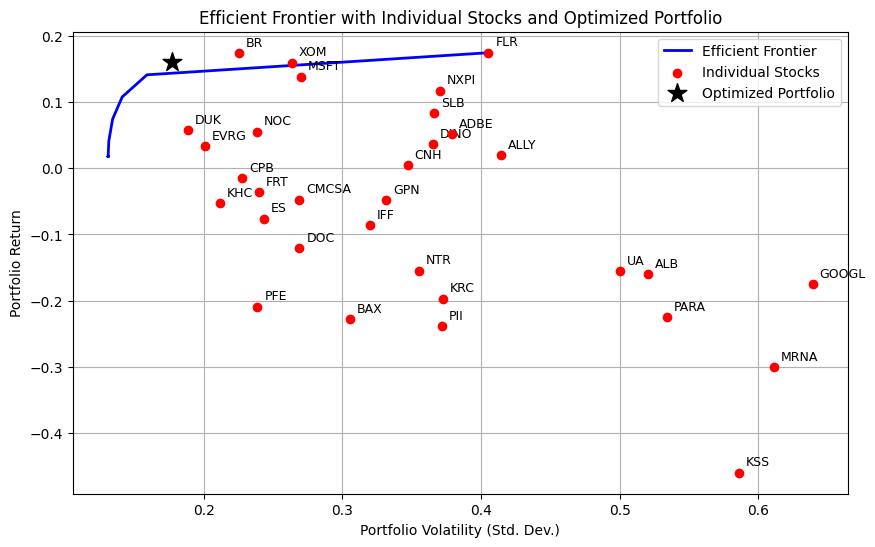

In [ ]:
frontier_points = []
target_returns = np.linspace(min(mu), max(mu), 20)
for t in target_returns:
    try:
        res = mean_variance_optimizer(
            expected_returns=mu,
            cov_matrix=Sigma,
            mode="minimize_variance",
            target_return=t,
            max_stocks=None  
        )
        frontier_points.append(res)
    except Exception as e:
        print(f"Target return {t:.4f} infeasible: {e}")
plot_efficient_frontier(mu, Sigma, frontier_points, result, stock_labels=prices_df.columns)